# Projection of the risk free curve and recalibration

## Table of contents

1. [Importing files](#section-1)
2. [Preparation and treatment of the curves](#section-2)
    - [The curves class](#curves-class)
    - [Save the input term structure](#input-term-structure)
    - [Calculate 1 year forward rates](#forward-rates)
    - [Forward yield curve](#forward-yield-curve)
3. [Calibrate Smith-Wilson on each yield curve](#section-3)
    - [Calibration of the interpolation/extrapolation algorithm](#calibration)
    - [Does the input curve's length explain it?](#alpha-diagnostic)
    - [Spread treatment](#spread-treatment)
4. [Example 1: the algorithm retains the liquid points](#section-4)
5. [Example 2: yields for arbitrary maturities](#section-5)
    - [Yield calculation](#yield-calculation)
    - [Capitalisation factor calculation](#capitalisation)
    - [Discount factor calculation](#discount)

The purpose of this workbook is to showcase the calibration methodology inside OSEM. The key to the calibration is the Smith Wilson algorithm commonly used in insurance. This algorithm allows a continuous approximation of arbitrary maturities based on a subset of available maturities. This example is split onto 3 parts. 

 - The first part shows how the necessary parameters and curves are imported from input files. 
 - Second part shows how the curves are generated and the Smith-Wilson calibrations derived. 
 - The last part shows how the saved calibration can be used to derive the discount rates for any maturity.

In [1]:
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
import sys

base_folder = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "ALM.ini").is_file())
sys.path.insert(0, str(base_folder / "src"))
import os
os.chdir(base_folder)

In [2]:
from osem.ImportData import import_SWEiopa
from osem.CurvesClass import Curves

<a id="section-1"></a>

## 1. Importing files

The parameters and the current risk free curve are provided as input:

 - Parameters.csv; Parameters related to the run 
 - EIOPA_param_file.csv; Assumed yield curve at modelling date and relevant maturities
 - EIOPA_curves_file.csv; Parameters related to the EIOPA time 0 calibration
 
 
 The exact location of the EIOPA files is encoded in the Parameters input file. 

In [3]:
paramfile = pd.read_csv("Input/Parameters.csv", index_col="Parameter")

The location of the two EIOPA files are:

In [4]:
selected_param_file = paramfile["Value"].loc["EIOPA_param_file"]
selected_curves_file = paramfile["Value"].loc["EIOPA_curves_file"]

The risk free curve belongs to the following country:

In [5]:
country = paramfile["Value"].loc["country"]

Import all necessary parameters:

In [6]:
[maturities_country, curve_country, extra_param, Qb] = import_SWEiopa(selected_param_file, selected_curves_file, country)

<a id="section-2"></a>

## 2. Preparation and treatment of the curves

The OSEM does multiple steps in order to make it easier for OSEM to access discount curves at any point in time and for arbitrary maturities. All steps are performed and saved within the Curves class.

<a id="curves-class"></a>

### The curves class

The curve class object contains all the data necessary to run the model.

In [7]:
# ultimate forward rate
ufr = extra_param["UFR"]/100

# Numeric precision of the optimisation
precision = float(paramfile["Value"].loc["Precision"])

# Targeted distance between the extrapolated curve and the ultimate forward rate at the convergence point
tau = float(paramfile["Value"].loc["Tau"])# 1 basis point

# A real date, as main.py passes. Note that Curves stores country but never uses
# initial_date, so this value does not affect any result.
modelling_date = datetime.datetime.strptime(
    paramfile["Value"].loc["Modelling_Date"], "%d/%m/%Y").date()

# Number of projection years
n_years = int(paramfile.loc["n_proj_years"].values[0])

In [8]:
curves = Curves(ufr, precision, tau, modelling_date, country)

After the Curves class is initiated, there are a series of calibrations that needs to be performed.

 - Saving of the input term structure
 - Calculation of the forward rates
 - Projection of the forward spot rates
 - Calculation of the Smith-Wilson calibrations for each period

<a id="input-term-structure"></a>

### Save the input term structure

SetObservedTermStructure sets the liquid maturities and the corresponding yields to the m_obs and r_obs property of the Curves class. 

In [9]:
curves.set_observed_term_structure(maturity_vec=curve_country.index.to_numpy(dtype=float), yield_vec=curve_country.values)

The term structure that every later step is built from:

***

In [10]:
input_curve = pd.DataFrame({"Maturity": curves.m_obs_ini["Maturity"],
                            "Yield": curves.r_obs_ini["Yield"]})

display(input_curve.head(10))

,Maturity,Yield
0,1.0,0.03472
1,2.0,0.03315
2,3.0,0.03140
3,4.0,0.03009
4,5.0,0.02930
5,6.0,0.02886
6,7.0,0.02860
7,8.0,0.02847
8,9.0,0.02845
9,10.0,0.02850


***

<a id="forward-rates"></a>

### Calculate 1 year forward rates

Using the time 0 spot curve provided as input, the yearly forward rates can be calculated from the annually reported yield curve. `calc_fwd_rates` stores the **capitalisation factor** $1 + fw_i$ rather than the rate itself, so the column `fwd_rates["Forward"]` holds values around 1.03, not 0.03.

For the first year:

$$
1 + fw_{EIOPA,1} = 1 + y_1
$$

otherwise:

$$
1 + fw_{EIOPA,i} = \frac{(1 + y_i)^{i}}{(1 + y_{i-1})^{i-1}}
$$

Note that this implementation assumes that all forward rates are exactly 1 year apart as provided by EIOPA.

Where:

 - $i$ is the year (Ex. 1,2,3, $\dots$)
 - $y_i$ is the yield for the year $i$
 - $fw_{EIOPA,i}$ is the 1-year forward rate between years $i-1$ and $i$

In [11]:
curves.calc_fwd_rates()

Note the third column: the stored values sit around 1.03, because `fwd_rates` holds the
capitalisation factor $1 + fw$ rather than the rate itself.

***

In [12]:
forward_table = pd.DataFrame({"Maturity": curves.m_obs_ini["Maturity"],
                              "Input yield": curves.r_obs_ini["Yield"],
                              "1 + forward": curves.fwd_rates["Forward"]})
forward_table["Forward rate"] = forward_table["1 + forward"] - 1

display(forward_table.head(10))

,Maturity,Input yield,1 + forward,Forward rate
0,1.0,0.03472,1.034720,0.034720
1,2.0,0.03315,1.031582,0.031582
2,3.0,0.03140,1.027909,0.027909
3,4.0,0.03009,1.026170,0.026170
4,5.0,0.02930,1.026146,0.026146
5,6.0,0.02886,1.026663,0.026663
6,7.0,0.02860,1.027041,0.027041
7,8.0,0.02847,1.027560,0.027560
8,9.0,0.02845,1.028290,0.028290
9,10.0,0.02850,1.028950,0.028950


***

<a id="forward-yield-curve"></a>

### Forward yield curve

The forward yield curve can be calculated by using the 1-year forward rates from the suitable moment onwards. The spot yield curve is calculated for each projection period. For the projection period $i$, the yield curve can be calculated as:

$$
1 + y^j_m = \left(\prod_{k=j+1}^{j+m}\big(1+fw_{EIOPA}(k)\big)\right)^{1/m}
$$

The spot rate is the geometric mean of the capitalisation factors covering the period, less one. In particular the shortest point of each projected curve is just the forward rate for that year, $y^j_1 = fw_{EIOPA}(j+1)$.

Where:
 - $j$ is the modelling period at which the model is performing the calculations
 - $m$ is the maturity measured from the start of modelling period $j$
 - $y^j_m$ is the yield $m$ years after the modelling period $j$
 - $fw_{EIOPA}(k)$ is the 1-year forward rate covering the year from $k-1$ to $k$

In [13]:
# The +1 matches main.py: the projected curve has to reach one year past the end of
# the modelling window so the last projection period can still be priced.
curves.project_forward_rate(n_years+1)

Two properties the projection has to satisfy. Year 0 is the input curve itself, and the
shortest point of each projected curve is the 1-year forward rate covering that year:

***

In [14]:
projection_check = pd.DataFrame({"Input yield": curves.r_obs_ini["Yield"],
                                 "Projected year 0": curves.r_obs["Yield_year_0"]})
projection_check["Difference"] = (projection_check["Projected year 0"]
                                  - projection_check["Input yield"])

one_year = pd.DataFrame(
    {"1-year spot of year j": [curves.r_obs["Yield_year_" + str(j)].dropna().values[0]
                               for j in range(1, 6)],
     "Forward rate j+1": [curves.fwd_rates["Forward"].values[j] - 1 for j in range(1, 6)]},
    index=["year " + str(j) for j in range(1, 6)],
)
one_year["Difference"] = one_year["1-year spot of year j"] - one_year["Forward rate j+1"]

display(projection_check.head(8))
display(one_year)

,Input yield,Projected year 0,Difference
0,0.03472,0.03472,8.326673e-17
1,0.03315,0.03315,1.387779e-17
2,0.03140,0.03140,9.714451e-17
3,0.03009,0.03009,-4.857226e-17
4,0.02930,0.02930,1.040834e-16
5,0.02886,0.02886,1.075529e-16
6,0.02860,0.02860,-4.163336e-17
7,0.02847,0.02847,-3.469447e-18


,1-year spot of year j,Forward rate j+1,Difference
year 1,0.031582,0.031582,0.0
year 2,0.027909,0.027909,0.0
year 3,0.026170,0.026170,0.0
year 4,0.026146,0.026146,0.0
year 5,0.026663,0.026663,0.0


***

<a id="section-3"></a>

## 3. Calibrate Smith-Wilson on each yield curve

Each forward yield curve is used to calibrate the SW algorithm. This calibration can then be used to generate yield curves of arbitrary maturities. The calibration is split on two parts. First one calibrates the curve at time 0.

<a id="calibration"></a>

### Calibration of the interpolation/extrapolation algorithm

Both at time 0 and in following projection years, the same calibration algorithm is performed. The algorithm looks to minimize the difference between the extrapolated forward intensity at the convergence point and the ultimate forward intensity, as recommended by EIOPA:


$$
T = \max(U+40,60)
$$

$$
g(\alpha) = |f(T) - \omega| = \frac{\alpha}{|1-\kappa e^{\alpha T}|}
$$

The calibration consists of using a bisection algorithm to minimize the difference between the ultimate forward rate $\omega$.

The calibration is:

$$
\min \alpha
$$

subject to constraints:

$$
\alpha \geq \alpha_{min}
$$
and

$$
g(\alpha) \leq \tau
$$

 And $\kappa$ is defined as:

 $$
\kappa = \frac{1 + \alpha u^T Qb}{sinh(\alpha u^T)Qb}
 $$

 $$
Q = d I C
 $$

$$
d = e^{-\omega u}
$$



Where:
 - $\alpha$ is the free parameter to be calibrated
 - $\alpha_{min}$ is the lower bound of the allowable values
 - $U$ is the last liquid point, the longest maturity in the input curve
 - $T$ is the convergence point at which the extrapolated curve must have reached the ultimate forward rate
 - $g(\alpha)$ is the gap at the convergence point between the extrapolated forward intensity $f(T)$ and the ultimate forward intensity $\omega$
 - $\omega = \ln(1 + ufr)$ is the ultimate forward intensity
 - $\tau$ is the largest gap that is still accepted at the convergence point
 - $u$ is the vector of liquid maturities used in the calibration
 - $C$ is a matrix of cash flows, the identity matrix here since the inputs are treated as zero-coupon bonds with a notional of 1
 - $d$ is the vector of ultimate-forward discount factors at those maturities
 - $b$ is the Smith-Wilson calibration vector returned by `sw_calibrate`

In the implementation, `g_alfa` returns $g(\alpha) - \tau$ and `bisection_alpha` finds its root, that is the $\alpha$ at which the constraint binds. Because the gap shrinks as $\alpha$ grows, that root is the smallest admissible $\alpha$.

In [15]:
curves.calibrate_projected(n_years+1, 0.05, 0.5, 1000)

The calibration produces one convergence speed $\alpha$ per projection year.

Every year here returns `0.05`, the lower end of the bracket passed to `calibrate_projected`.
That is the correct answer rather than a failure: with this input $g(\alpha)$ stays below $\tau$
across the whole bracket, so the constraint $g(\alpha) \leq \tau$ is satisfied everywhere and the
EIOPA rule *minimise* $\alpha$ selects the smallest admissible value. `bisection_alpha` detects
that case explicitly; it used to walk to the far end of the bracket and return `0.5`, the largest
value, instead. The next subsection shows what drives which case you land in.

***

In [16]:
alpha_table = pd.DataFrame(
    {"Alpha": [curves.alpha["Alpha_year_" + str(j)][0] for j in range(n_years + 1)]},
    index=["year " + str(j) for j in range(n_years + 1)],
)

display(alpha_table.head(10))
print("distinct calibrated alphas:", sorted(alpha_table["Alpha"].unique()))

,Alpha
year 0,0.05
year 1,0.05
year 2,0.05
year 3,0.05
year 4,0.05
year 5,0.05
year 6,0.05
year 7,0.05
year 8,0.05
year 9,0.05


distinct calibrated alphas: [np.float64(0.05)]


***

<a id="alpha-diagnostic"></a>

### Does the input curve's length explain it?

The convergence point is $T = \max(U + 40, 60)$, so a long last liquid point $U$ pushes $T$ far
out and the extrapolation has already reached the ultimate forward rate whatever $\alpha$ is. The
table below rebuilds the calibration on the input curve truncated at a range of last liquid
points, using throwaway `Curves` objects so nothing above or below is affected.

`Bracketed` is the condition the bisection needs: $g$ must change sign across
$[\alpha_{min}, \alpha_{max}]$ for a root to exist.

***

In [17]:
alpha_by_last_point = []
maturities_all = curve_country.index.to_numpy(dtype=float)

for last_point in (150, 100, 70, 60, 50, 48, 47, 40, 30, 20):
    keep = maturities_all <= last_point
    m_cut = maturities_all[keep]
    r_cut = curve_country.values[keep]

    probe = Curves(ufr, precision, tau, modelling_date, country)
    probe.set_observed_term_structure(maturity_vec=m_cut, yield_vec=r_cut)

    alpha_by_last_point.append({
        "Last liquid point": last_point,
        "Convergence point T": max(last_point + 40, 60),
        "g(0.05)": probe.g_alfa(m_cut, r_cut, probe.ufr, 0.05, tau),
        "g(0.50)": probe.g_alfa(m_cut, r_cut, probe.ufr, 0.50, tau),
        "Calibrated alpha": probe.bisection_alpha(0.05, 0.5, m_cut, r_cut,
                                                  probe.ufr, tau, precision, 1000),
    })

alpha_diagnostic = pd.DataFrame(alpha_by_last_point).set_index("Last liquid point")
alpha_diagnostic["Bracketed"] = (np.sign(alpha_diagnostic["g(0.05)"])
                                 != np.sign(alpha_diagnostic["g(0.50)"]))

display(alpha_diagnostic)

,Convergence point T,g(0.05),g(0.50),Calibrated alpha,Bracketed
Last liquid point,,,,,
150,190,-0.000071,-0.0001,0.050000,False
100,140,-0.000002,-0.0001,0.050000,False
70,110,-0.000081,-0.0001,0.050000,False
60,100,-0.000094,-0.0001,0.050000,False
50,90,-0.000084,-0.0001,0.050000,False
48,88,-0.000035,-0.0001,0.050000,False
47,87,0.000003,-0.0001,0.050657,True
40,80,0.000034,-0.0001,0.057355,True
30,70,0.000344,-0.0001,0.087499,True


***

Truncating the curve to 50 years does **not** change the situation: $g$ is still negative at both
ends of the bracket, so there is no root and the calibration returns the lower bound. A root only
appears at a last liquid point of 47 years and below, where $\alpha$ is genuinely determined by
the data rather than by the edge of the bracket. At a last liquid point of 20 years, EIOPA's
actual value for the euro, the calibration gives about 0.118, close to EIOPA's published $\alpha$.

Note that truncating the input for real is not an option here. The projection consumes one
maturity per year, so a curve of 50 points cannot support 51 projection years:
`project_forward_rate` runs out of maturities and `calibrate_projected` raises `ValueError: max()
iterable argument is empty`. The input curve has to be longer than the projection horizon, which
is why it runs to 150 years in the first place.

<a id="spread-treatment"></a>

### Spread treatment

`retrieve_rates` takes a `spread` argument and adds it to the extrapolated yield as a parallel shift, after the Smith-Wilson extrapolation rather than inside it:

$$
y_{spread}(v) = y(v) + s
$$

Every quantity derived from the yield therefore carries the shift too, so the capitalisation and discount factors become $(1 + y(v) + s)^{v}$ and $(1 + y(v) + s)^{-v}$. This is the mechanism the asset classes use to price with a credit spread: bonds pass their calibrated z-spread, equities the sum of their country, sector and stress spreads. Every example below uses `spread = 0` and therefore prices off the risk free curve alone.

<a id="section-4"></a>

## 4. Example 1: the algorithm retains the liquid points

One of the properties of the Smith-Wilson algorithm is that it retains the curve values at the liquid points provided in the calibration. This property is tested in the first example. A projection year is selected and the algorithm is asked to provide the values using the calibration vector. The original yield curve that was used to calibrate is then compared to the output.

In [18]:
spread = 0.00

In [19]:
p_year = 6

In [20]:
interpolated_curve = curves.retrieve_rates(p_year, curves.m_obs["Maturities_year_"+str(p_year)].values[:-p_year], "Yield",spread=spread)

Quantifying what the chart below shows:

***

In [21]:
example_1_check = pd.DataFrame({
    "Maturity": curves.m_obs["Maturities_year_" + str(p_year)].values[:-p_year],
    "Provided": curves.r_obs["Yield_year_" + str(p_year)].values[:-p_year],
    "Recalculated": np.asarray(interpolated_curve).ravel(),
})
example_1_check["Difference"] = (example_1_check["Recalculated"]
                                 - example_1_check["Provided"])

display(example_1_check.head(10))
print(f"max |difference| over all {len(example_1_check)} liquid points: "
      f"{example_1_check['Difference'].abs().max():.3e}")

,Maturity,Provided,Recalculated,Difference
0,1.0,0.027041,0.027041,1.269651e-12
1,2.0,0.027301,0.027301,1.107114e-12
2,3.0,0.027630,0.027630,8.935075e-13
3,4.0,0.027960,0.027960,8.737455e-13
4,5.0,0.027782,0.027782,5.333511e-13
5,6.0,0.028540,0.028540,4.074519e-13
6,7.0,0.028916,0.028916,3.541611e-13
7,8.0,0.028825,0.028825,2.635669e-13
8,9.0,0.028427,0.028427,7.793766e-14
9,10.0,0.027868,0.027868,1.065814e-14


max |difference| over all 144 liquid points: 1.908e-12


***

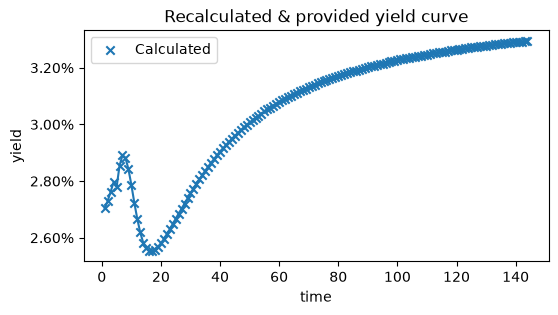

In [22]:
fig, ax1 = plt.subplots(1, 1)
ax1.scatter(curves.m_obs["Maturities_year_"+str(p_year)].values[:-p_year], interpolated_curve*100, label="Calculated", marker="x")
ax1.plot(curves.m_obs["Maturities_year_"+str(p_year)].values[:-p_year], curves.r_obs["Yield_year_"+str(p_year)].values[:-p_year]*100)
ax1.set_ylabel("yield")
ax1.set_title('Recalculated & provided yield curve')
ax1.set_xlabel("time")
ax1.legend()
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
fig.set_figwidth(6)
fig.set_figheight(3)
plt.show()

***

<a id="section-5"></a>

## 5. Example 2: yields for arbitrary maturities

The calibration will be used to provide OSEM with yields for arbitrary maturities. This example verifies if the calibration provides yields for maturities not provided as input into the calibration.
Assuming the algorithm is processing the year 3. A hypothetical asset has a cash flow at year fractions:

$$ \{0.7, 1.2, 1.3543\} $$

To make it possible to calculate the present value, the corresponding discount rates are calculated:


With the calibrated vector $b$, the required yields can easily be obtained by applying the formula:

$$
p(v) = e^{-\omega v} \big(1 + H(v,u) Q b \big)
$$

and converting the resulting prices to annualised yields:

$$
y(v) = p(v)^{-1/v} - 1
$$

Where:
 - $v$ is the vector of desired maturities
 - $ \omega $ is the ultimate forward intensity
 - $u$ is the vector of maturities that were used in the calibration
 - $H(v,u)$ is the Heart of the Wilson function
 - $Q$ and $b$ are as defined in the calibration section above

In [23]:
desired_mat = np.array([0.7, 1.2, 1.3543])

<a id="yield-calculation"></a>

### Yield calculation


The yield in each modelling period can be interpolated/extrapolated using the Smith-Wilson calibration vector calculated above. This allows OSEM to apply continuous yields.

In [24]:
spread = 0.0

***

In [25]:
display(curves.retrieve_rates(3, desired_mat, "Yield",spread))

,Yield
0,0.026187
1,0.026155
2,0.026145


***

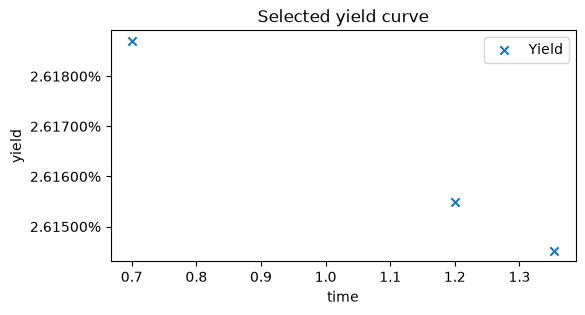

In [26]:
fig, ax1 = plt.subplots(1, 1)
ax1.scatter(desired_mat, curves.retrieve_rates(3, desired_mat, "Yield", spread)*100, label="Yield", marker="x")
ax1.set_ylabel("yield")
ax1.set_title('Selected yield curve')
ax1.set_xlabel("time")
ax1.legend()
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
fig.set_figwidth(6)
fig.set_figheight(3)
plt.show()

***

<a id="capitalisation"></a>

### Capitalisation factor calculation


The capitalisation factor can be calculated as:

$$
c_i(t) = \big(1+ y_i(t)\big)^{t} 
$$


***

In [27]:
display(curves.retrieve_rates(3, desired_mat, "Capitalisation", spread))

,Capitalisation
0,1.018260
1,1.031467
2,1.035571


***

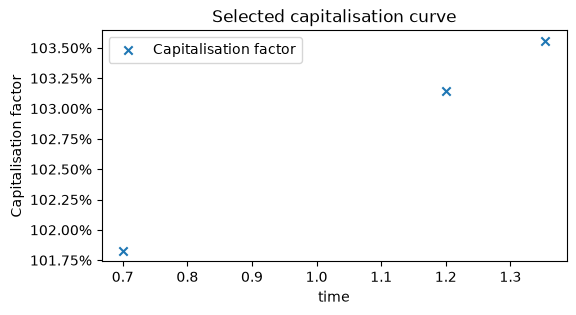

In [28]:
fig, ax1 = plt.subplots(1, 1)
ax1.scatter(desired_mat, curves.retrieve_rates(3, desired_mat, "Capitalisation", spread)*100, label="Capitalisation factor", marker="x")
ax1.set_ylabel("Capitalisation factor")
ax1.set_title('Selected capitalisation curve')
ax1.set_xlabel("time")
ax1.legend()
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
fig.set_figwidth(6)
fig.set_figheight(3)
plt.show()

***

<a id="discount"></a>

### Discount factor calculation

The discount factors can be calculated from the yield:

$$
d_i(t) = \big(1+ y_i(t)\big)^{-t} 
$$

Where:
 - $t$ is time increment from the modelling period (Ex. 1.5 is 1 year and 6 months after the modelling period
 - $y_i(t)$ is the annualized yield for maturity t after the modelling period $i$
 - $c_i(t)$ is the capitalisation factor for 1 unit, until $t$ years after the modelling period $i$

 - $d_i(t)$ is the discount factor for a cash flow of value 1, occurring $t$ years after the modelling period $i$, discounted to the modelling period $i$


***

In [29]:
display(curves.retrieve_rates(3, desired_mat, "Discount", spread))

,Discount
0,0.982068
1,0.969493
2,0.965650


***

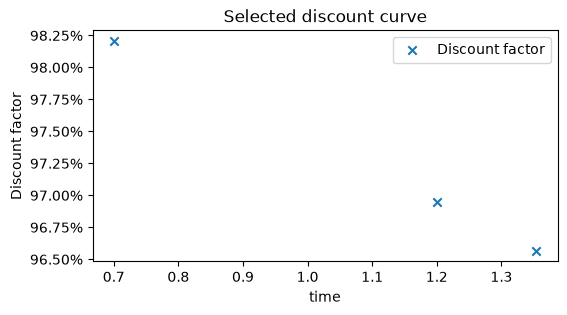

In [30]:
fig, ax1 = plt.subplots(1, 1)
ax1.scatter(desired_mat, curves.retrieve_rates(3, desired_mat, "Discount", spread)*100, label="Discount factor", marker="x")
ax1.set_ylabel("Discount factor")
ax1.set_title('Selected discount curve')
ax1.set_xlabel("time")
ax1.legend()
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
fig.set_figwidth(6)
fig.set_figheight(3)
plt.show()

***